# Total Time Spent on Question
Checks the time the candidate spend on a question. 

The test will be marked as "too slow" if the time it took was more than the mean plus the standard deviation and marked as "too fast" if the time it took was more than the mean minus the standard deviation. 

The mean and the standard deviation are calculated over all questions with the same ItemId. 

In [1]:
import pandas as pd
import pyodbc  
import matplotlib.pyplot as plt

## Import Data from csv

In [2]:
fca_question = pd.read_csv("../../../decoded_data/FCA/FactQuestionFCA.csv")

## Data Inspection

In [3]:
fca_question.head()

,FCAQuestionKey,TestKey,Competence1Key,Competence2Key,Competence3Key,Competence4Key,ItemId,Answer1,Answer2,Answer3,TimeSpent
0,1,1,1,0,0,0,222,0,0,0,11
1,2,1,2,183,0,0,223,3,4,2,3
2,3,1,3,184,0,0,226,4,3,2,13
3,4,1,4,0,0,0,229,2,0,4,100
4,5,1,5,0,0,0,238,0,0,0,2


In [4]:
fca_question.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035705 entries, 0 to 3035704
Data columns (total 11 columns):
 #   Column          Dtype
---  ------          -----
 0   FCAQuestionKey  int64
 1   TestKey         int64
 2   Competence1Key  int64
 3   Competence2Key  int64
 4   Competence3Key  int64
 5   Competence4Key  int64
 6   ItemId          int64
 7   Answer1         int64
 8   Answer2         int64
 9   Answer3         int64
 10  TimeSpent       int64
dtypes: int64(11)
memory usage: 254.8 MB


## Detection Function

The standerd deviation can return Nan if the variation is too small. We will in that case work with zero. 

In [5]:
df_items = fca_question[["ItemId", "TimeSpent"]]

df_items = df_items.groupby('ItemId')['TimeSpent'].agg(['mean', 'std']).reset_index().rename(columns={"mean":"MeanTimeSpent", "std":"StdTimeSpent"})
df_items.fillna(0, inplace=True)
df_items.set_index("ItemId", inplace=True)
df_items.head()

,MeanTimeSpent,StdTimeSpent
ItemId,,
117,523.724138,338.376317
118,264.603448,251.121861
119,201.060345,113.197272
120,113.739130,101.904590
121,167.622807,116.470923


In [6]:
df_items["MaxTime"] = df_items["MeanTimeSpent"] + df_items["StdTimeSpent"]
df_items["MinTime"] = df_items["MeanTimeSpent"] - df_items["StdTimeSpent"]
df_items.head()

,MeanTimeSpent,StdTimeSpent,MaxTime,MinTime
ItemId,,,,
117,523.724138,338.376317,862.100455,185.347821
118,264.603448,251.121861,515.725310,13.481587
119,201.060345,113.197272,314.257617,87.863073
120,113.739130,101.904590,215.643720,11.834541
121,167.622807,116.470923,284.093730,51.151884


In [ ]:
df = fca_question[["QuestionKey", "ItemId", "TimeSpent"]]
df.head()

,FCAQuestionKey,ItemId,TimeSpent
0,1,222,11
1,2,223,3
2,3,226,13
3,4,229,100
4,5,238,2


In [8]:
def detect_too_slow(ItemId, TimeSpent):
    if TimeSpent > df_items.MaxTime[ItemId]:
        return True
    return False

def detect_too_fast(ItemId, TimeSpent):
    if TimeSpent < df_items.MinTime[ItemId]:
        return True
    return False

## Data Labelling

In [9]:
df["TooSlow"] = df.apply(lambda row: detect_too_slow(row['ItemId'], row['TimeSpent']), axis=1)
df["TooFast"] = df.apply(lambda row: detect_too_fast(row['ItemId'], row['TimeSpent']), axis=1)

df.head()

C:\Users\monad\AppData\Local\Temp\ipykernel_24892\3736623771.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TooSlow"] = df.apply(lambda row: detect_too_slow(row['ItemId'], row['TimeSpent']), axis=1)
C:\Users\monad\AppData\Local\Temp\ipykernel_24892\3736623771.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TooFast"] = df.apply(lambda row: detect_too_fast(row['ItemId'], row['TimeSpent']), axis=1)


,FCAQuestionKey,ItemId,TimeSpent,TooSlow,TooFast
0,1,222,11,False,False
1,2,223,3,False,False
2,3,226,13,False,False
3,4,229,100,False,False
4,5,238,2,False,False


## Exporting Data with Anomaly Check

In [ ]:
df.set_index("QuestionKey", inplace=True)
df.to_csv("../csv/time_spent_question_checked.csv")
df

,ItemId,TimeSpent,TooSlow,TooFast
FCAQuestionKey,,,,
1,222,11,False,False
2,223,3,False,False
3,226,13,False,False
4,229,100,False,False
5,238,2,False,False
...,...,...,...,...
3035701,422,80,False,False
3035702,423,98,False,False
3035703,424,126,False,False


## Visualisation

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

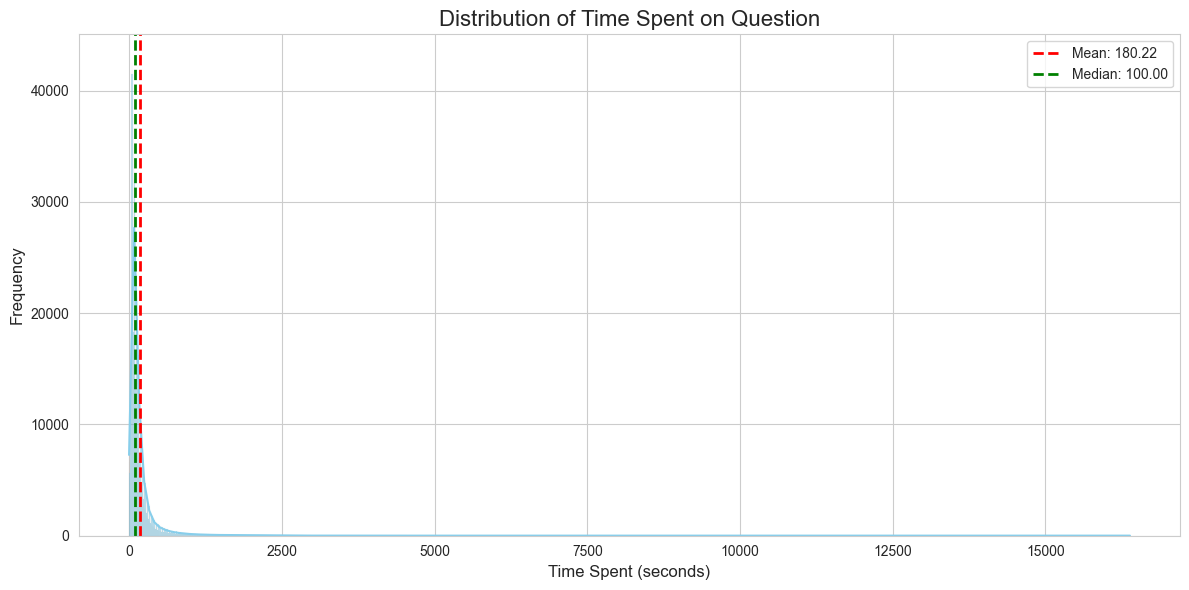

In [12]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# kernel density estimation
sns.histplot(data=df, x='TimeSpent', kde=True, color='skyblue', edgecolor='black')

# name 
plt.title('Distribution of Time Spent on Question', fontsize=16)
plt.xlabel('Time Spent (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add summary statistics
mean_time = df['TimeSpent'].mean()
median_time = df['TimeSpent'].median()

plt.axvline(mean_time, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_time:.2f}')
plt.axvline(median_time, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_time:.2f}')

plt.legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

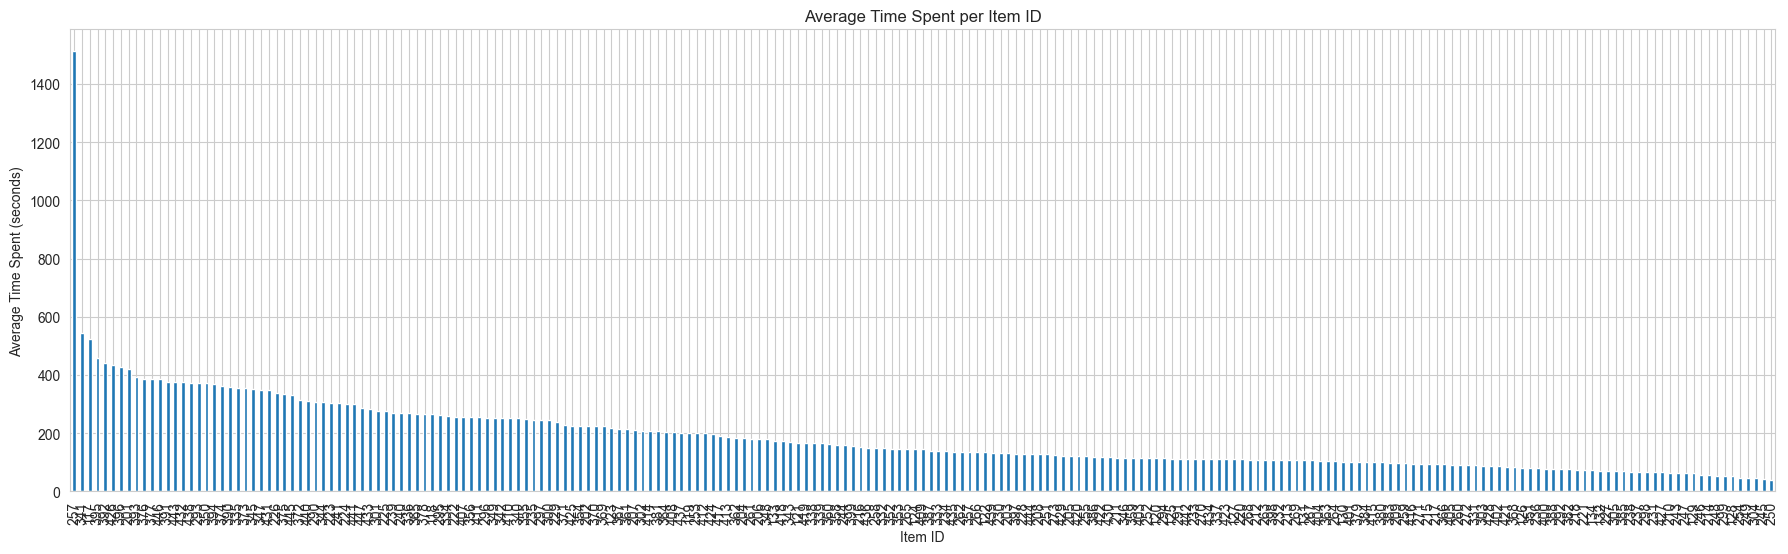

In [13]:
avg_time_per_item = df.groupby('ItemId')['TimeSpent'].mean().sort_values(ascending=False)
plt.figure(figsize=(22, 6))
avg_time_per_item.plot(kind='bar')
plt.title('Average Time Spent per Item ID')
plt.xlabel('Item ID')
plt.ylabel('Average Time Spent (seconds)')
plt.xticks(rotation=90)
plt.show()

In [ ]:
# pivot_table = df.pivot_table(values='TimeSpent', index='QuestionKey', columns='ItemId', aggfunc='mean')
# plt.figure(figsize=(12, 8))
# sns.heatmap(pivot_table, cmap='YlOrRd')
# plt.title('Heatmap of Time Spent on Question and Item')
# plt.xlabel('Item ID')
# plt.ylabel('Question ID')
# plt.show()

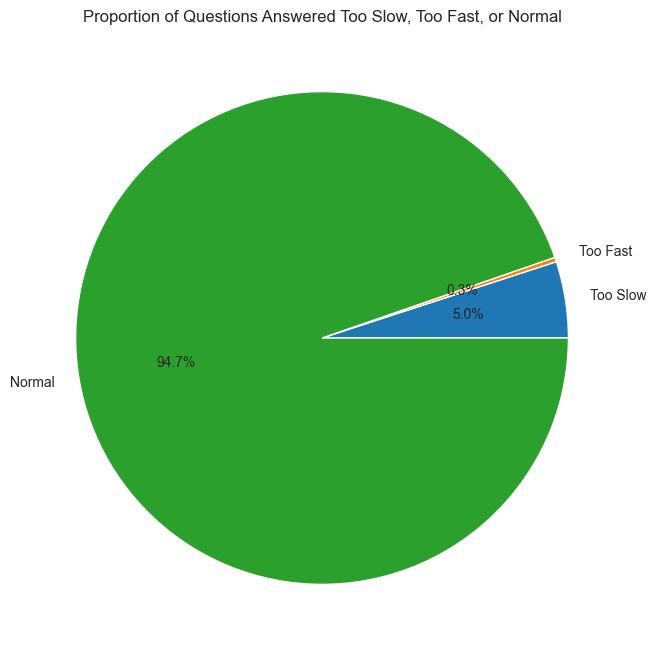

In [16]:
too_slow_count = df['TooSlow'].sum()
too_fast_count = df['TooFast'].sum()
normal_count = len(df) - too_slow_count - too_fast_count

plt.figure(figsize=(8, 8))
plt.pie([too_slow_count, too_fast_count, normal_count], 
        labels=['Too Slow', 'Too Fast', 'Normal'], 
        autopct='%1.1f%%')
plt.title('Proportion of Questions Answered Too Slow, Too Fast, or Normal')
plt.show()